# Segment Anything Model (SAM)

----

Conda env : [cv_playgrounds](../README.md#setup-a-conda-environment)

----

- Ref: 
    - https://docs.ultralytics.com/models/sam/#sam-prediction-example
    - https://colab.research.google.com/github/ultralytics/notebooks/blob/main/notebooks/inference-with-meta-sam-and-sam2-using-ultralytics-python-package.ipynb#scrollTo=7EM2nwU4jshF

In [1]:
!nvidia-smi

Thu Nov 20 18:45:08 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2080 Ti     On  |   00000000:01:00.0  On |                  N/A |
| 29%   41C    P5             30W /  250W |     441MiB /  11264MiB |     20%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [7]:
from ultralytics.utils.downloads import attempt_download_asset
path = attempt_download_asset("zidane.jpg", repo="ultralytics/assets", release="latest")
print(path)  # local path to zidane.jpg

zidane.jpg


In [10]:
from ultralytics import ASSETS, YOLO
from ultralytics import SAM

# Load a model
model = SAM("./temp_model/sam_b.pt")

# Display model information (optional)
model.info()

# Run inference with bboxes prompt
results = model(ASSETS / "zidane.jpg", bboxes=[439, 437, 524, 709])
print(results)

# Run inference with single point
results = model(points=[900, 370], labels=[1])

# Run inference with multiple points
results = model(points=[[400, 370], [900, 370]], labels=[1, 1])

# Run inference with multiple points prompt per object
results = model(points=[[[400, 370], [900, 370]]], labels=[[1, 1]])

# Run inference with negative points prompt
results = model(points=[[[400, 370], [900, 370]]], labels=[[1, 0]])

Model summary: 173 layers, 93,735,472 parameters, 93,735,472 gradients

image 1/1 /home/hyunjae/anaconda3/envs/cv_playgrounds/lib/python3.10/site-packages/ultralytics/assets/zidane.jpg: 1024x1024 1 0, 191.1ms
Speed: 3.5ms preprocess, 191.1ms inference, 0.5ms postprocess per image at shape (1, 3, 1024, 1024)
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: ultralytics.engine.results.Masks object
names: {0: '0'}
obb: None
orig_img: array([[[44, 51, 76],
        [43, 50, 75],
        [41, 48, 73],
        ...,
        [20, 18, 54],
        [18, 16, 52],
        [17, 15, 51]],

       [[44, 51, 76],
        [43, 50, 75],
        [41, 48, 73],
        ...,
        [20, 18, 54],
        [18, 16, 52],
        [18, 16, 52]],

       [[44, 51, 76],
        [43, 50, 75],
        [41, 48, 73],
        ...,
        [21, 18, 57],
        [19, 16, 55],
        [18, 15, 54]],

       ...,

       [[53, 44, 40],
        

### SAM - Segment Everything

Model summary: 403 layers, 80,850,178 parameters, 80,850,178 gradients

Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/bus.jpg: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 1 10, 1 11, 1 12, 1 13, 1 14, 1 15, 1 16, 1 17, 1 18, 1 19, 1 20, 1 21, 3615.7ms
Speed: 3.8ms preprocess, 3615.7ms inference, 0.9ms postprocess per image at shape (1, 3, 1024, 1024)


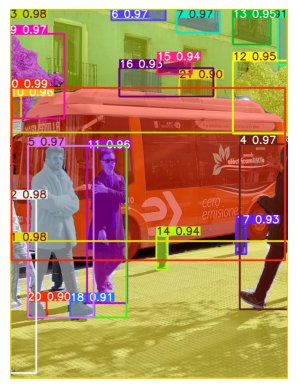

In [ ]:
from ultralytics import SAM
import matplotlib.pyplot as plt

# Load a model
# For SAM=sam_b.pt, SAM2=sam2_b.pt, SAM2.1=sam2.1_b.pt
model = SAM("./temp_model/sam2.1_b.pt")

model.info()  # Display model information (optional)

# Run inference (image or video)
results = model("https://ultralytics.com/images/bus.jpg")  # image
# results = model("https://youtu.be/LNwODJXcvt4")  # video file

# results[0].show()  # Display results

# Plot the bounding boxes on the image.
annotated_frame = results[0].plot()

# Display the annotated image using Matplotlib
# plt.figure(figsize=(12, 10)) # Optional: Adjust the figure size for better viewing
plt.figure()
plt.imshow(annotated_frame)
plt.axis('off') # Hide the axis
plt.show()

### SAM - Bounding box prompt


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/bus.jpg: 1024x1024 1 0, 156.1ms
Speed: 4.0ms preprocess, 156.1ms inference, 0.8ms postprocess per image at shape (1, 3, 1024, 1024)


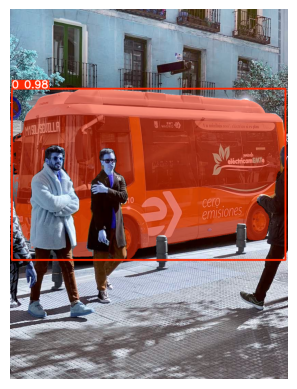

In [17]:
from ultralytics import SAM
import matplotlib.pyplot as plt

# Load a model
model = SAM("./temp_model/sam2.1_b.pt")

# Run inference with bboxes prompt (Provide the bounding box coordinates
# for the bus area, ensuring that only bus is segmented in the entire image)
results = model("https://ultralytics.com/images/bus.jpg",
                bboxes=[3.8328723907470703, 229.35601806640625,
                        796.2098999023438, 728.4313354492188])

# results[0].show()  # Display results

# Plot the bounding boxes on the image.
annotated_frame = results[0].plot()

# Display the annotated image using Matplotlib
# plt.figure(figsize=(12, 10)) # Optional: Adjust the figure size for better viewing
plt.figure()
plt.imshow(annotated_frame)
plt.axis('off') # Hide the axis
plt.show()

### SAM - Point prompt


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/bus.jpg: 1024x1024 1 0, 142.8ms
Speed: 3.6ms preprocess, 142.8ms inference, 0.5ms postprocess per image at shape (1, 3, 1024, 1024)


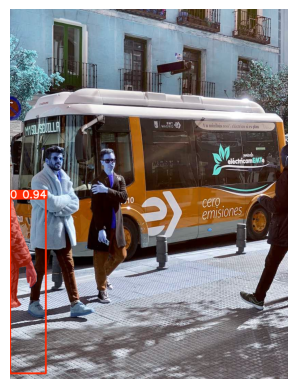

In [18]:
from ultralytics import SAM
import matplotlib.pyplot as plt

# Load a model
model = SAM("./temp_model/sam2.1_b.pt")

# Run inference with point prompt (Provide the point coordinates for the
# person area, ensuring that only the person is segmented in the entire image)
results = model("https://ultralytics.com/images/bus.jpg",
                points=[34, 714])

# results[0].show()  # Display results

# Plot the bounding boxes on the image.
annotated_frame = results[0].plot()

# Display the annotated image using Matplotlib
# plt.figure(figsize=(12, 10)) # Optional: Adjust the figure size for better viewing
plt.figure()
plt.imshow(annotated_frame)
plt.axis('off') # Hide the axis
plt.show()

### SAM - Multiple points prompt


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/bus.jpg: 1024x1024 1 0, 1 1, 136.6ms
Speed: 3.7ms preprocess, 136.6ms inference, 0.6ms postprocess per image at shape (1, 3, 1024, 1024)


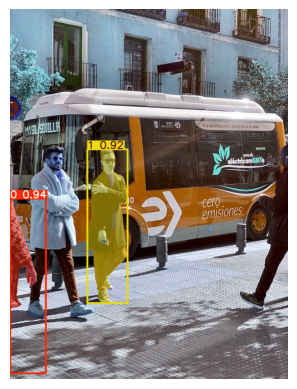

In [19]:
from ultralytics import SAM
import matplotlib.pyplot as plt

# Load a model
model = SAM("./temp_model/sam2.1_b.pt")

# Run inference with multiple point prompts (Provide the points coordinates for
# person area, ensuring that only the person is segmented in the entire image)
results = model("https://ultralytics.com/images/bus.jpg",
                points=[[34, 714], [283, 634]])

# results[0].show()  # Display results

# Plot the bounding boxes on the image.
annotated_frame = results[0].plot()

# Display the annotated image using Matplotlib
# plt.figure(figsize=(12, 10)) # Optional: Adjust the figure size for better viewing
plt.figure()
plt.imshow(annotated_frame)
plt.axis('off') # Hide the axis
plt.show()

### SAM - Auto Annotation using Segment Anything Model

In [4]:
from ultralytics.data.annotator import auto_annotate

# Use the Ultralytics sample dataset (You can use your own images)
from ultralytics.utils.downloads import safe_download
images = ["bus.jpg", "zidane.jpg"]
for img in images:
  path = safe_download(f"https://ultralytics.com/assets/{img}", dir="temp_assets")

# return the annotation in the Ultralytics YOLO segmentation format.
# output directory i.e assets_auto_annotate_labels
auto_annotate(data="temp_assets",
              det_model="./temp_model/yolo11x.pt",
              sam_model="./temp_model/sam_b.pt")


image 1/2 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/temp_assets/bus.jpg: 640x480 4 persons, 1 bus, 27.5ms
image 2/2 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/temp_assets/zidane.jpg: 384x640 2 persons, 3 ties, 17.2ms
Speed: 1.2ms preprocess, 22.3ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)


In [ ]:
from ultralytics import SAM
import matplotlib.pyplot as plt

# Load a model
model = SAM("./temp_model/sam2.1_b.pt")

# Run inference with point prompt (Provide the point coordinates for the
# person area, ensuring that only the person is segmented in the entire image)
results = model("https://youtu.be/LNwODJXcvt4")  # video file

results[0].show()  # Display results